In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/car_price_dataset.csv")
df

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [3]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [6]:
cat_col = ["Brand", "Model", "Fuel_Type", "Transmission"]
num_col = ["Year", "Engine_Size",	"Mileage", "Doors",	"Owner_Count",	"Price"]

uniq_val = {col: df[col].nunique() for col in cat_col}
for k, v in uniq_val.items():
  print(f"{k}: {v}")

Brand: 10
Model: 30
Fuel_Type: 4
Transmission: 3


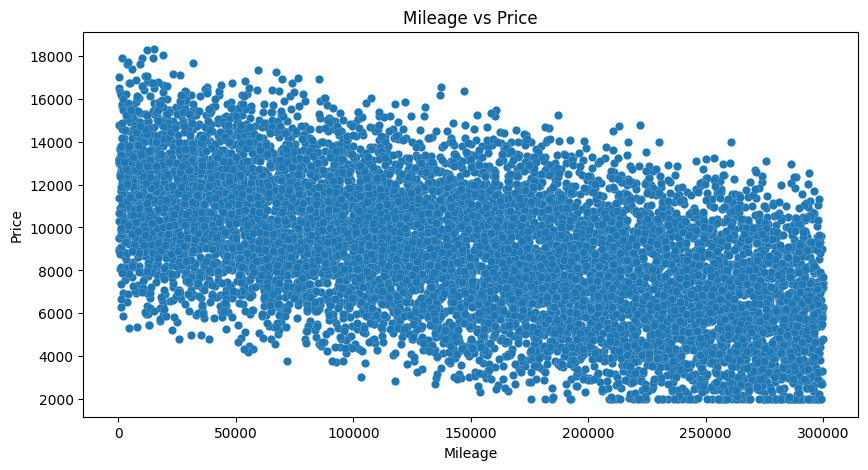

In [57]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Mileage"], y=df["Price"], linewidth=0.1)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

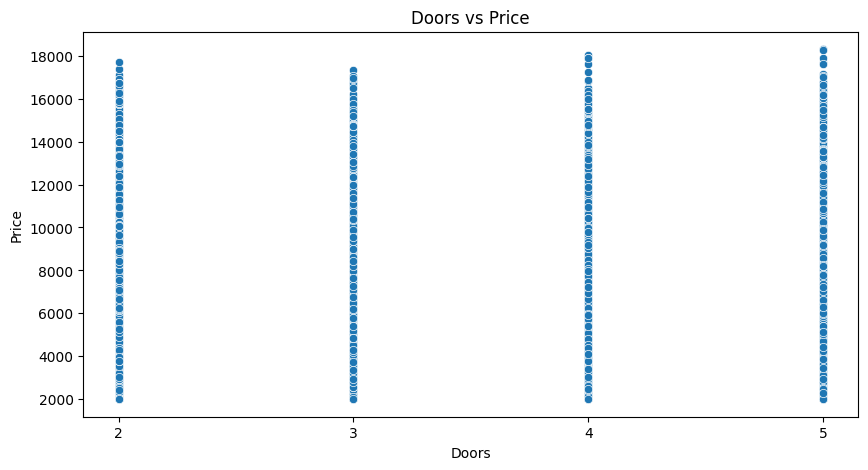

In [120]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Doors"], y=df["Price"])
plt.title("Doors vs Price")
plt.xlabel("Doors")
plt.xticks([2, 3, 4, 5])
plt.ylabel("Price")
plt.show()

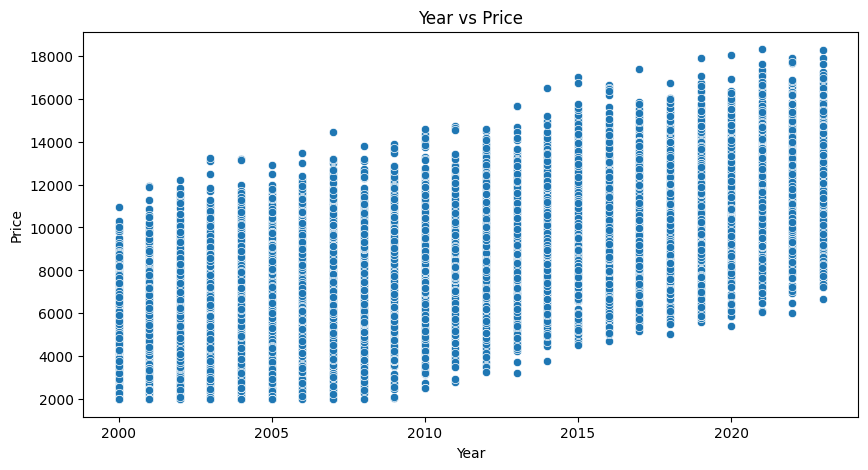

In [43]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Year"], y=df["Price"])
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

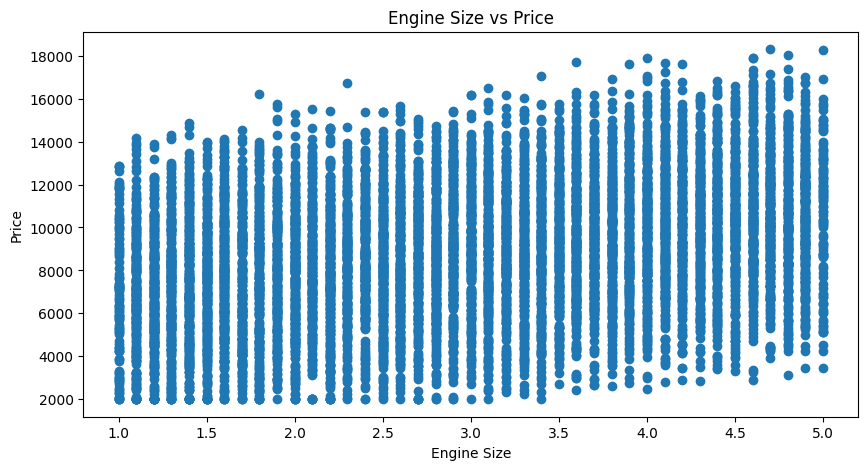

In [58]:
plt.figure(figsize=(10, 5))
plt.scatter(df["Engine_Size"], df["Price"])
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

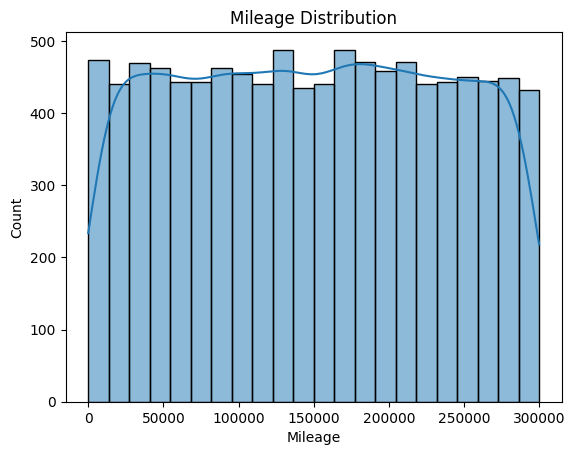

In [61]:
sns.histplot(df["Mileage"], kde=True)
plt.title("Mileage Distribution")
plt.show()

In [ ]:
df["Mileage"].skew()

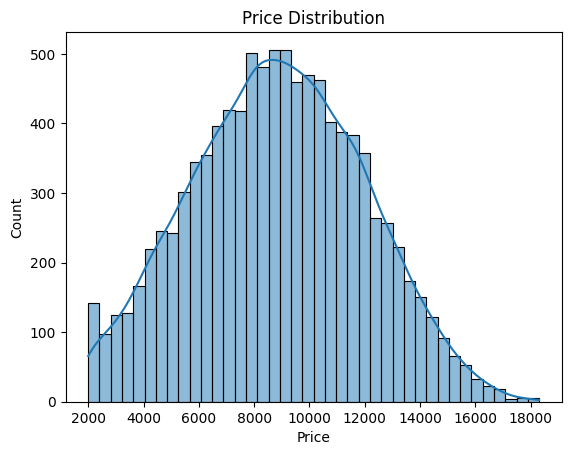

In [60]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

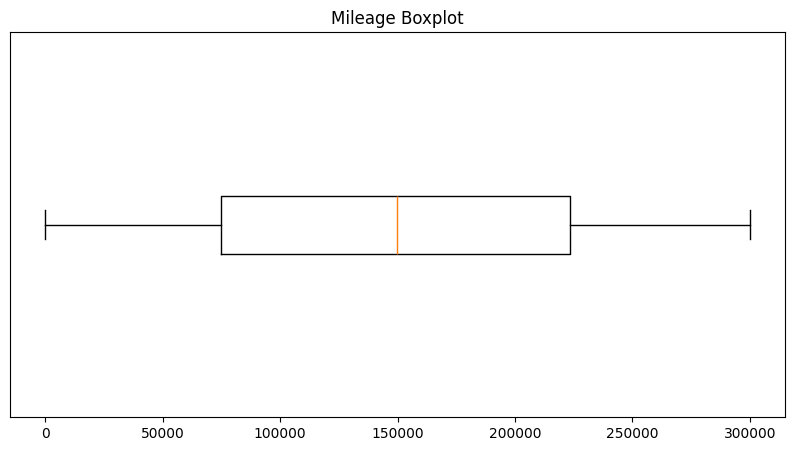

In [10]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["Mileage"], label="Mileage", vert=False, whis=1.5)
plt.yticks([])
plt.title("Mileage Boxplot")
plt.show()


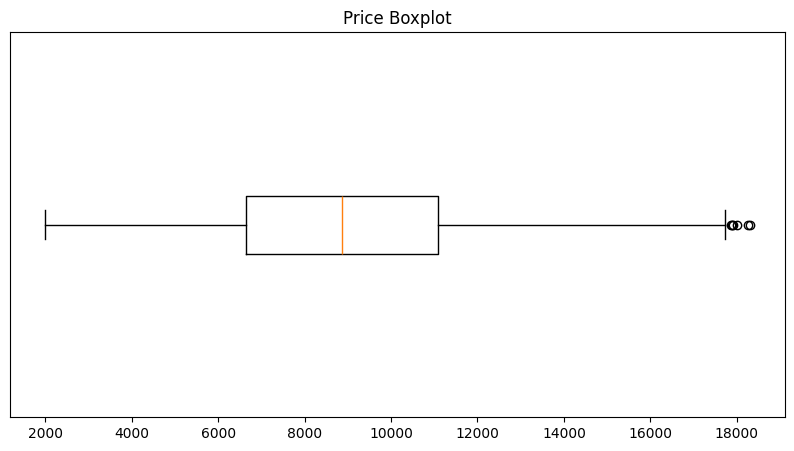

In [13]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["Price"], label="Price", vert=False, whis=1.5)
plt.yticks([])
plt.title("Price Boxplot")
plt.show()

In [29]:
mean_m = df["Mileage"].mean()
std_m = df["Mileage"].std()

lb = mean_m - 3 * std_m
ub = mean_m + 3 * std_m

o_m = df[(df["Mileage"] < lb) | (df["Mileage"] > ub)]
len(o_m)

0

In [34]:
mean_p = df["Price"].mean()
std_p = df["Price"].std()

lb = mean_p - 3 * std_p
ub = mean_p + 3 * std_p

o_p = df[(df["Price"] < lb) | (df["Price"] > ub)]
len(o_p)

2

In [15]:
Q1_m = df["Mileage"].quantile(0.25)
Q3_m = df["Mileage"].quantile(0.75)
IQR_m = Q3_m - Q1_m
IQR_m

np.float64(148928.25)

In [16]:
Q1_p = df["Price"].quantile(0.25)
Q3_p = df["Price"].quantile(0.75)
IQR_p = Q3_p - Q1_p
IQR_p

np.float64(4440.5)

In [17]:
lm = Q1_m - 1.5 * IQR_m
rm = Q3_m + 1.5 * IQR_m
lp = Q1_p - 1.5 * IQR_p
rp = Q3_p + 1.5 * IQR_p

In [20]:
outliers_m = df[(df["Mileage"] < lm) | (df["Mileage"] > rm)]
outliers_p = df[(df["Price"] < lp) | (df["Price"] > rp)]
print(f"Number of outliers in Mileage: {len(outliers_m)}")
print(f"Number of outliers in Price: {len(outliers_p)}")

Number of outliers in Mileage: 0
Number of outliers in Price: 6


In [22]:
df_cleaned = df.copy()
outliers_index = outliers_m.index.union(outliers_p.index)
df_cleaned.drop(outliers_index, inplace=True)
df_cleaned.reset_index(drop=True, inplace=True)

In [23]:
df_cleaned

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9989,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9990,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9991,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9992,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


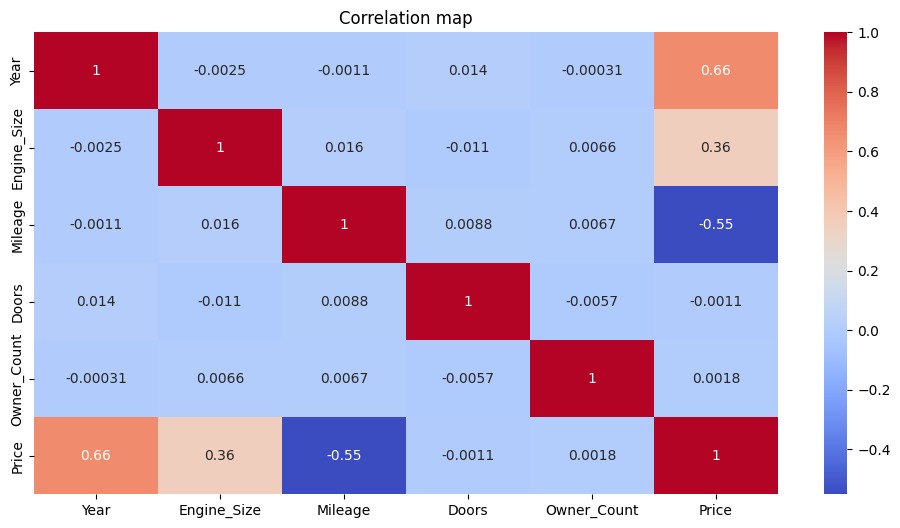

In [25]:
corr = df_cleaned[num_col].corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation map")
plt.show()

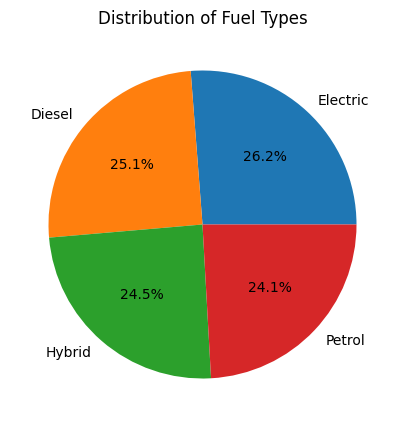

In [71]:
plt.figure(figsize=(10,5))
fuel_count = df_cleaned["Fuel_Type"].value_counts()
plt.pie(fuel_count, labels=fuel_count.index, autopct="%1.1f%%")
plt.title("Distribution of Fuel Types")
plt.show()

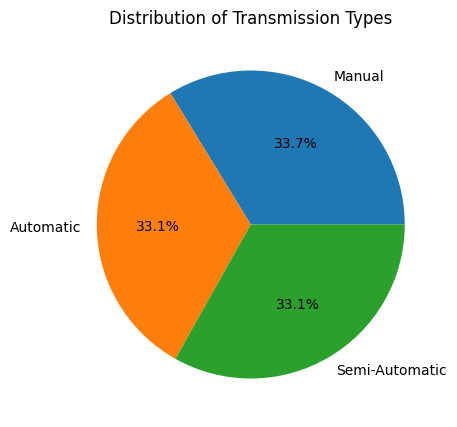

In [72]:
plt.figure(figsize=(10, 5))
trmsn_type = df_cleaned["Transmission"].value_counts()
plt.pie(trmsn_type, labels=trmsn_type.index, autopct="%1.1f%%")
plt.title("Distribution of Transmission Types")
plt.show()

In [78]:
brand_avg_price = df_cleaned.groupby("Brand")["Price"].mean().sort_values()

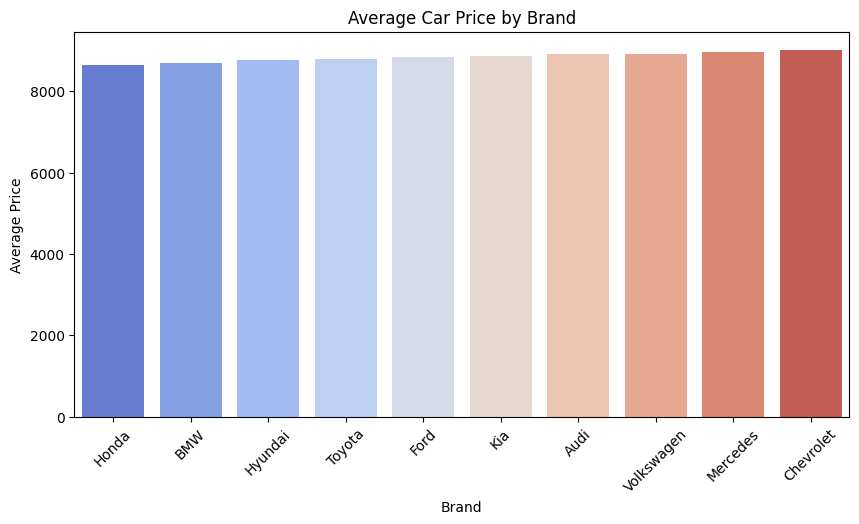

In [99]:
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_avg_price.index, y=brand_avg_price.values, hue=brand_avg_price.index, palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.title("Average Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

In [100]:
brand_avg_mls = df_cleaned.groupby("Brand")["Mileage"].mean().sort_values()
brand_avg_mls

,Mileage
Brand,
Mercedes,145502.817410
Chevrolet,146740.873380
Volkswagen,147367.759804
Toyota,149315.004128
Kia,149408.309426
BMW,149980.309309
Hyundai,149986.231388
Ford,150775.924546
Audi,151108.074253


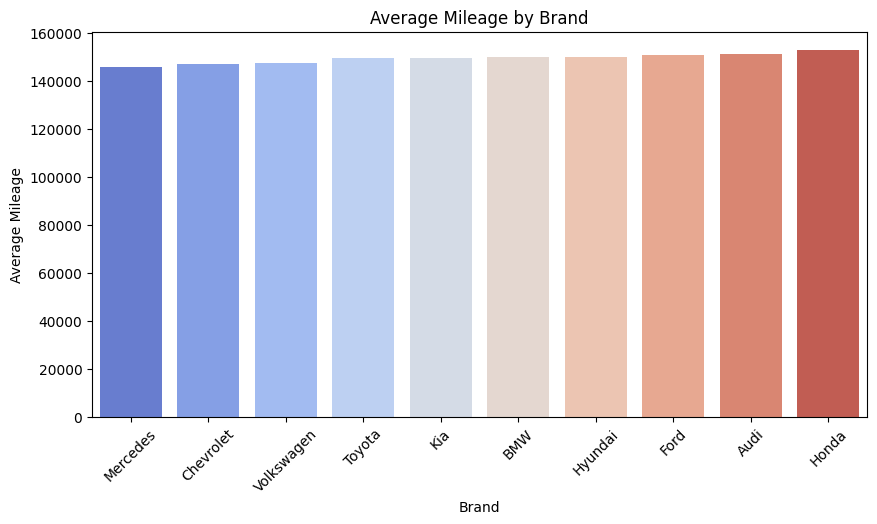

In [102]:
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_avg_mls.index, y=brand_avg_mls.values, hue=brand_avg_mls.index, palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.title("Average Mileage by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Mileage")
plt.show()

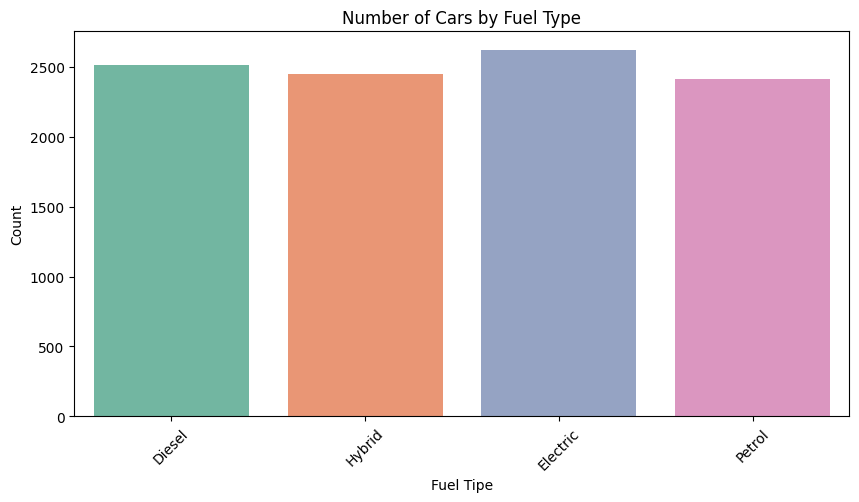

In [104]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df_cleaned["Fuel_Type"], hue=df_cleaned["Fuel_Type"], palette="Set2", legend=False)
plt.xticks(rotation=45)
plt.title("Number of Cars by Fuel Type", fontsize=12)
plt.xlabel("Fuel Tipe")
plt.ylabel("Count")
plt.show()

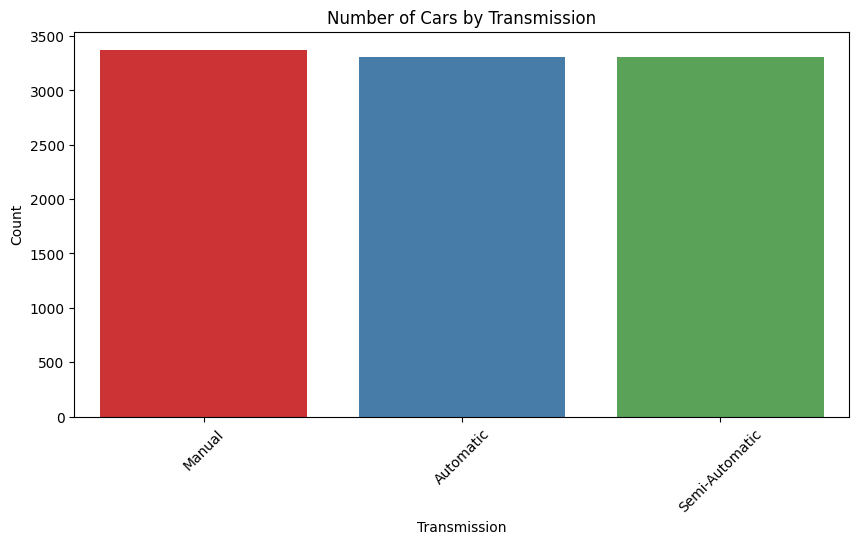

In [105]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df_cleaned["Transmission"], hue=df_cleaned["Transmission"], palette="Set1", legend=False)
plt.xticks(rotation=45)
plt.title("Number of Cars by Transmission", fontsize=12)
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.show()

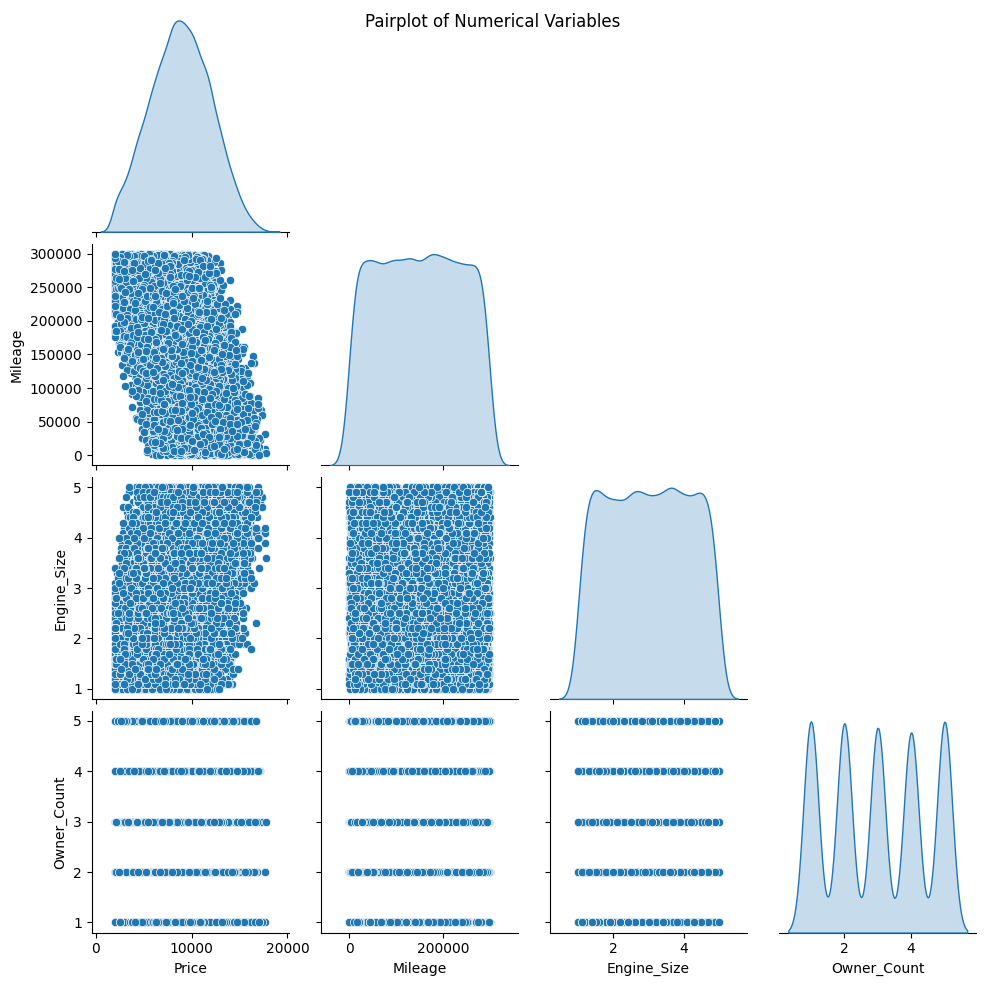

In [110]:
sns.pairplot(df_cleaned, vars=["Price", "Mileage", "Engine_Size", "Owner_Count"], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Numerical Variables")
plt.show()

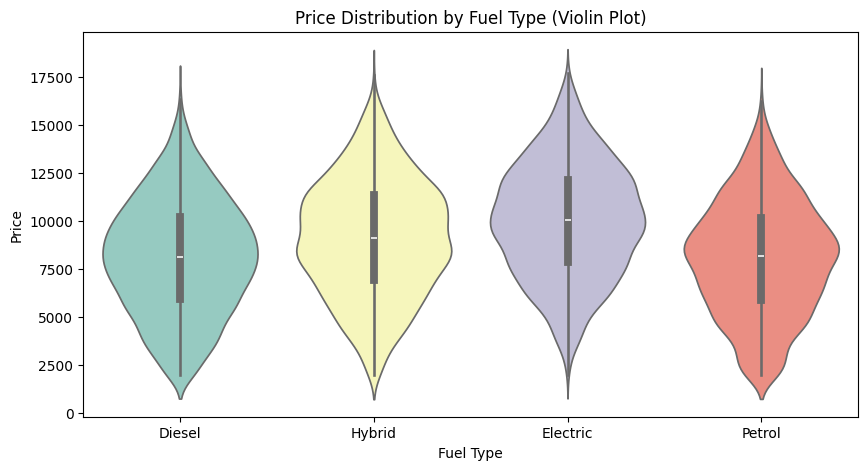

In [122]:
plt.figure(figsize=(10, 5))
sns.violinplot(x=df_cleaned["Fuel_Type"], y=df_cleaned["Price"], hue=df_cleaned["Fuel_Type"], palette="Set3", legend=False)
plt.title("Price Distribution by Fuel Type (Violin Plot)")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()


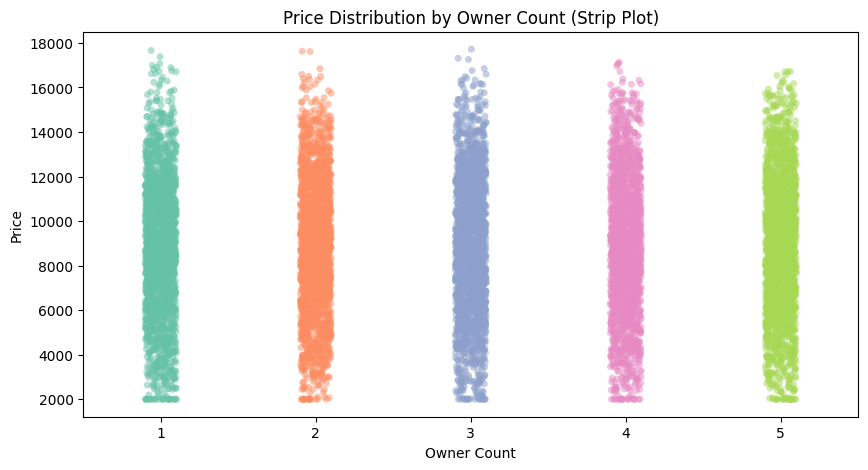

In [132]:
plt.figure(figsize=(10, 5))
sns.stripplot(x=df_cleaned["Owner_Count"], y=df_cleaned["Price"], hue=df_cleaned["Owner_Count"], jitter=True, palette="Set2", legend=False, alpha=0.5)
plt.title("Price Distribution by Owner Count (Strip Plot)")
plt.xlabel("Owner Count")
plt.ylabel("Price")
plt.show()

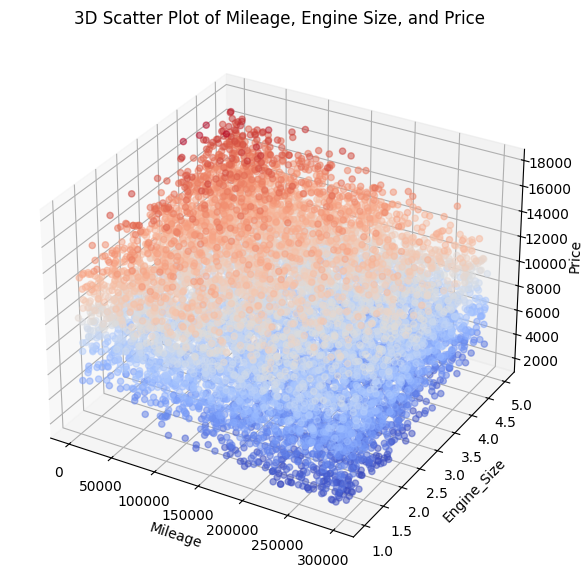

In [135]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_cleaned['Mileage'], df_cleaned['Engine_Size'], df_cleaned['Price'], alpha=0.5, c=df_cleaned["Price"], cmap="coolwarm")
ax.set_xlabel('Mileage')
ax.set_ylabel('Engine_Size')
ax.set_zlabel('Price')
ax.set_title('3D Scatter Plot of Mileage, Engine Size, and Price')
plt.show()

In [137]:
df_reg = df_cleaned[num_col]
df_reg

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
0,2020,4.2,289944,3,5,8501
1,2012,2.0,5356,2,3,12092
2,2020,4.2,231440,4,2,11171
3,2023,2.0,160971,2,1,11780
4,2003,2.6,286618,3,3,2867
...,...,...,...,...,...,...
9989,2004,3.7,5794,2,4,8884
9990,2002,1.4,168000,2,1,6240
9991,2010,3.0,86664,5,1,9866
9992,2002,1.4,225772,4,1,4084


In [193]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_reg.drop(columns="Price")
y = df_reg["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=537)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled)
X_test_df = pd.DataFrame(X_test_scaled)

In [194]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

models_full = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Ridge Regression": Ridge(alpha=0.5, solver="auto"),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=5000),
    "ElasticNet Regression": ElasticNet(alpha=0.001, l1_ratio=0.7, max_iter=5000),
}

In [196]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import time

result = []

for n, model in models_full.items():
    try:
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        elapsed_time = time.time() - start_time
        result.append({
            "Model": n,
            "MSE": mse,
            "MAE": mae,
            "R2": r2,
            "Time": elapsed_time
        })
    except Exception as e:
        result.append({
            "Model": n,
            "MSE": None,
            "MAE": None,
            "R2": None,
            "Time": None,
            "Error": str(e)
        })

In [197]:
result_df_full = pd.DataFrame(result)
result_df_full["Performance_Score"] = result_df_full["R2"] / result_df_full["Time"]
result_df_sorted_optimized = result_df_full.sort_values(by="Performance_Score", ascending=False)
result_df_sorted_optimized

,Model,MSE,MAE,R2,Time,Performance_Score
3,ElasticNet Regression,1.224954e+06,933.796721,0.872165,0.003572,244.184336
2,Lasso Regression,1.224922e+06,933.794348,0.872168,0.004702,185.504045
1,Ridge Regression,1.224932e+06,933.795146,0.872167,0.005135,169.837740
0,Linear Regression,1.224922e+06,933.794354,0.872168,0.012569,69.392032


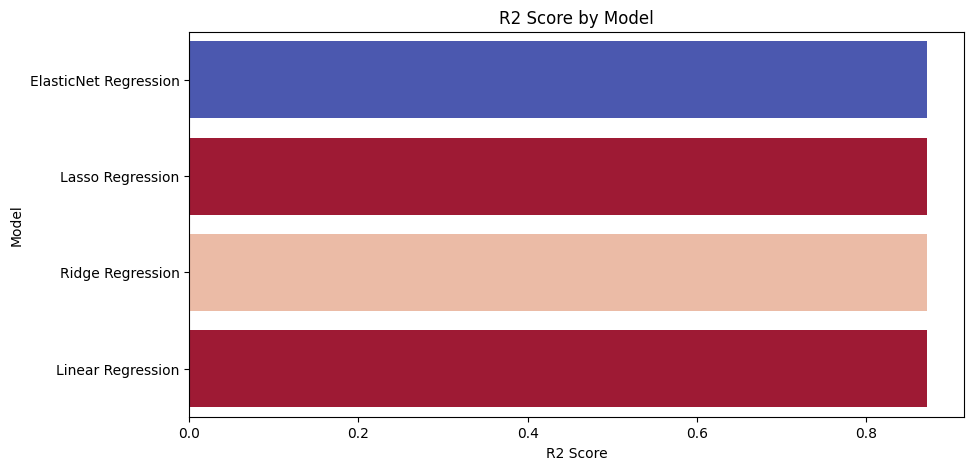

In [198]:
plt.figure(figsize=(10, 5))
sns.barplot(x=result_df_sorted_optimized["R2"], y=result_df_sorted_optimized["Model"], hue=result_df_sorted_optimized["R2"], palette="coolwarm", legend=False)
plt.title("R2 Score by Model")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.show()

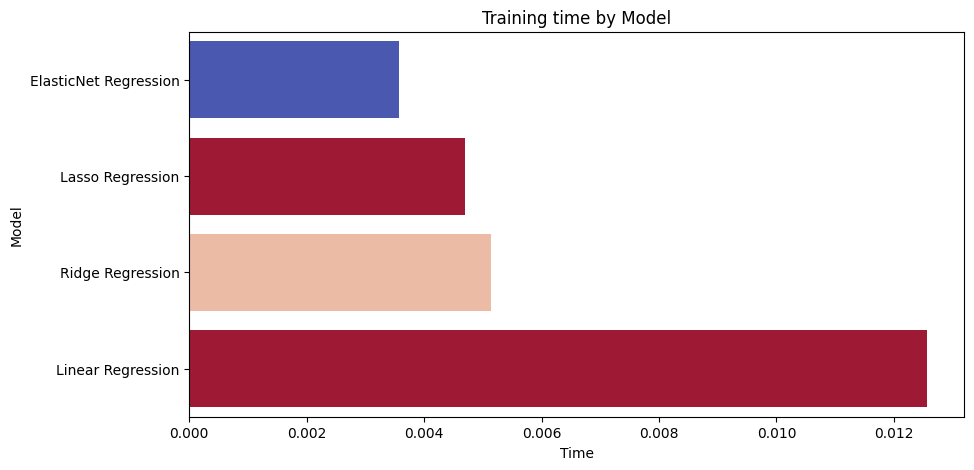

In [199]:
plt.figure(figsize=(10, 5))
sns.barplot(x=result_df_sorted_optimized["Time"], y=result_df_sorted_optimized["Model"], hue=result_df_sorted_optimized["R2"], palette="coolwarm", legend=False)
plt.title("Training time by Model")
plt.xlabel("Time")
plt.ylabel("Model")
plt.show()

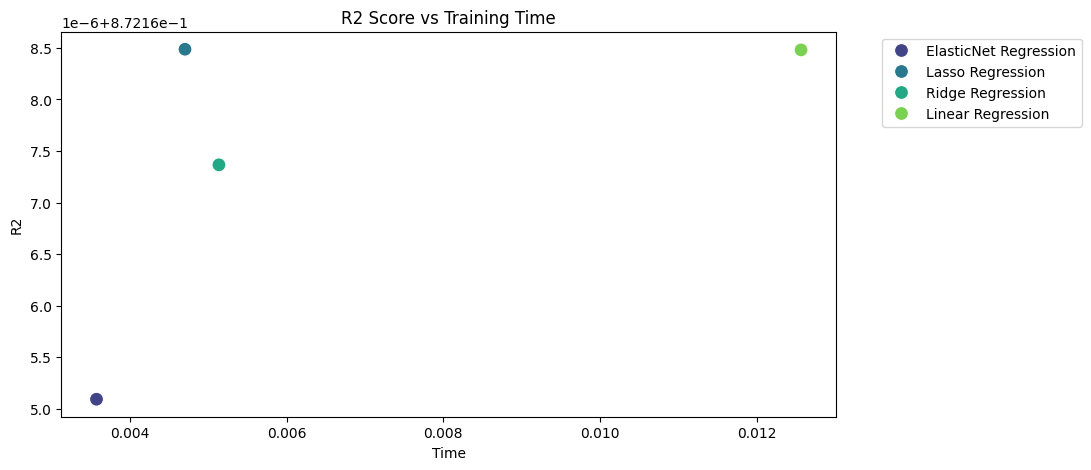

In [200]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=result_df_sorted_optimized["Time"], y=result_df_sorted_optimized["R2"], hue=result_df_sorted_optimized["Model"], palette="viridis", s=100)
plt.title("R2 Score vs Training Time")
plt.xlabel("Time")
plt.ylabel("R2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

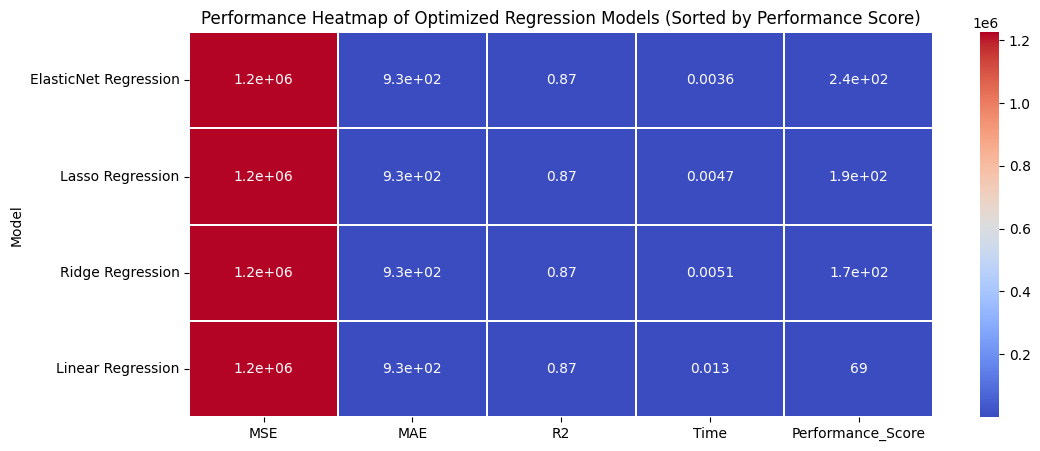

In [201]:
plt.figure(figsize=(12, 5))
sns.heatmap(result_df_sorted_optimized.set_index("Model"), annot=True, cmap="coolwarm", linewidths=0.3)
plt.title("Performance Heatmap of Optimized Regression Models (Sorted by Performance Score)", fontsize=12)
plt.show()

https://auto.ru/cars/used/sale/bmw/3er/1133708869-4b419369/

https://auto.ru/cars/used/sale/mercedes/c_klasse/1133678722-c982371a/

https://auto.ru/cars/used/sale/hyundai/tucson/1133687808-6eea9a1a/

https://auto.ru/cars/used/sale/audi/s8/1132939079-9566d259/

https://auto.ru/cars/used/sale/vaz/granta/1133699913-c6c603bd/

In [202]:
Xd = [{'Year': 2024,
  'Engine_Size': 2.0,
  'Mileage': 22764,
  'Doors': 4,
  'Owner_Count': 1},

 {'Year': 2024,
  'Engine_Size': 2.0,
  'Mileage': 22150 ,
  'Doors': 4,
  'Owner_Count': 1},

 {'Year': 2024,
  'Engine_Size': 2.0,
  'Mileage': 63876,
  'Doors': 5,
  'Owner_Count': 1},

 {'Year': 2025,
  'Engine_Size': 4.0,
  'Mileage': 37,
  'Doors': 4,
  'Owner_Count': 1},

 {'Year': 2025,
  'Engine_Size': 1.6,
  'Mileage': 3300,
  'Doors': 5,
  'Owner_Count': 1}]

In [209]:
X_eval = pd.DataFrame(Xd)
X_eval


,Year,Engine_Size,Mileage,Doors,Owner_Count
0,2024,2.0,22764,4,1
1,2024,2.0,22150,4,1
2,2024,2.0,63876,5,1
3,2025,4.0,37,4,1
4,2025,1.6,3300,5,1


In [210]:
X_eval_scaled = scaler.transform(X_eval)
X_eval_scaled

array([[ 1.79808559, -0.85481284, -1.46564446,  0.43250921, -1.41139775],
       [ 1.79808559, -0.85481284, -1.47274488,  0.43250921, -1.41139775],
       [ 1.79808559, -0.85481284, -0.99021692,  1.33190518, -1.41139775],
       [ 1.94288404,  0.88585008, -1.72846412,  0.43250921, -1.41139775],
       [ 1.94288404, -1.20294543, -1.69073012,  1.33190518, -1.41139775]])

In [218]:
pred_df = X_eval.copy()

for n, model in models_full.items():
    pred_df[n] = model.predict(X_eval_scaled)

pred_df

,Year,Engine_Size,Mileage,Doors,Owner_Count,Linear Regression,Ridge Regression,Lasso Regression,ElasticNet Regression
0,2024,2.0,22764,4,1,14060.421651,14059.913489,14060.420301,14058.897443
1,2024,2.0,22150,4,1,14072.654166,14072.144770,14072.652808,14071.126254
2,2024,2.0,63876,5,1,13248.512660,13248.090319,13248.510939,13247.245448
3,2025,4.0,37,4,1,16786.879321,16786.094097,16786.875790,16784.523061
4,2025,1.6,3300,5,1,14357.891554,14357.358810,14357.889317,14356.293037


In [219]:
RUB_USD = 90

rub_price = [3800000, 4990000, 3649900, 21500000, 1100000]
usd_price = [int(x / RUB_USD) for x in rub_price]
pred_df["Auto_Price"] = usd_price
pred_df

,Year,Engine_Size,Mileage,Doors,Owner_Count,Linear Regression,Ridge Regression,Lasso Regression,ElasticNet Regression,Auto_Price
0,2024,2.0,22764,4,1,14060.421651,14059.913489,14060.420301,14058.897443,42222
1,2024,2.0,22150,4,1,14072.654166,14072.144770,14072.652808,14071.126254,55444
2,2024,2.0,63876,5,1,13248.512660,13248.090319,13248.510939,13247.245448,40554
3,2025,4.0,37,4,1,16786.879321,16786.094097,16786.875790,16784.523061,238888
4,2025,1.6,3300,5,1,14357.891554,14357.358810,14357.889317,14356.293037,12222
